In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/declared_track_survey.csv')
df.head()

,Timestamp,What is your current year of study?,Have you decided on your specialization track?,"To what extent do you agree with the following statement: \n""The process of choosing my track was clear and well-guided.""\n\n(1 = Strongly Disagree; 2 = Disagree; 3 = Neutral; 4 = Agree; 5 = Strongly Agree)",Please elaborate on your experience. What made the process clear or unclear for you?,Which sources did you rely on MOST to understand different tracks? (Select up to 2),Which of the following do you feel is MOST lacking in your decision process?,"Looking back, how helpful would the following tool have been in supporting your track decision? \na) Short simulation of real-world tasks from each track\n\n(1 = Not Useful; 2 = Slightly Useful; 3 = Moderately Useful; 4 = Useful; 5 = Very Useful)","Looking back, how helpful would the following tool have been in supporting your track decision? \n b) Personalized track recommendation based on my profile\n\n(1 = Not Useful; 2 = Slightly Useful; 3 = Moderately Useful; 4 = Useful; 5 = Very Useful)","After selecting your specialization track, how well do you understand how it translates into real-world applications and job roles (e.g. projects, internships, career paths)?\n\n(1 = Not at all; 2 = Slightly; 3 = Moderately; 4 = Mostly; 5 = Completely)"
0,2026/04/03 11:46:53 am GMT+8,Year 2,Yes,4,I consulted some of my seniors as well as a ca...,Seniors;Career talks,Hands-on exposure to tasks,5,4,4
1,2026/04/03 11:50:16 am GMT+8,Year 2,Yes,5,I was sure that I wanted the least coding poss...,Seniors;Friends / peers,Understanding of career outcomes,5,5,5
2,2026/04/03 11:51:37 am GMT+8,Year 2,Yes,4,"I knew what mods I gravitated more towards, as...","Seniors;School platforms (Oasis, website)",Hands-on exposure to tasks,5,5,4
3,2026/04/03 11:53:57 am GMT+8,Year 2,Yes,3,Not having sufficient information on the types...,"School platforms (Oasis, website);Friends / peers",Real-world examples of jobs,4,4,3
4,2026/04/03 11:58:11 am GMT+8,Year 2,Yes,5,"Was already sure of what I wanted, so choosing...",Seniors;Friends / peers,Hands-on exposure to tasks,4,4,5


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Shape: (65, 10)

Columns:
0: Timestamp
1: What is your current year of study?
2: Have you decided on your specialization track?
3: To what extent do you agree with the following statement: 
"The process of choosing my track was clear and well-guided."

(1 = Strongly Disagree; 2 = Disagree; 3 = Neutral; 4 = Agree; 5 = Strongly Agree)
4: Please elaborate on your experience. What made the process clear or unclear for you?
5: Which sources did you rely on MOST to understand different tracks? (Select up to 2)
6: Which of the following do you feel is MOST lacking in your decision process?
7: Looking back, how helpful would the following tool have been in supporting your track decision? 
a) Short simulation of real-world tasks from each track

(1 = Not Useful; 2 = Slightly Useful; 3 = Moderately Useful; 4 = Useful; 5 = Very Useful)
8: Looking back, how helpful would the following tool have been in supporting your track decision? 
 b) Personalized track recommendation based on my profile

(1 =

In [4]:
df.columns = [
    "timestamp",
    "year",
    "track_decided",
    "clarity_rating",
    "experience",
    "info_sources",
    "decision_gap",
    "simulation_useful",
    "recommendation_useful",
    "realworld_understanding"
]

df.head()

,timestamp,year,track_decided,clarity_rating,experience,info_sources,decision_gap,simulation_useful,recommendation_useful,realworld_understanding
0,2026/04/03 11:46:53 am GMT+8,Year 2,Yes,4,I consulted some of my seniors as well as a ca...,Seniors;Career talks,Hands-on exposure to tasks,5,4,4
1,2026/04/03 11:50:16 am GMT+8,Year 2,Yes,5,I was sure that I wanted the least coding poss...,Seniors;Friends / peers,Understanding of career outcomes,5,5,5
2,2026/04/03 11:51:37 am GMT+8,Year 2,Yes,4,"I knew what mods I gravitated more towards, as...","Seniors;School platforms (Oasis, website)",Hands-on exposure to tasks,5,5,4
3,2026/04/03 11:53:57 am GMT+8,Year 2,Yes,3,Not having sufficient information on the types...,"School platforms (Oasis, website);Friends / peers",Real-world examples of jobs,4,4,3
4,2026/04/03 11:58:11 am GMT+8,Year 2,Yes,5,"Was already sure of what I wanted, so choosing...",Seniors;Friends / peers,Hands-on exposure to tasks,4,4,5


In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"].str.replace(" GMT+8", "", regex=False),
    format="%Y/%m/%d %I:%M:%S %p"
)

df["timestamp"].head()

0   2026-04-03 11:46:53
1   2026-04-03 11:50:16
2   2026-04-03 11:51:37
3   2026-04-03 11:53:57
4   2026-04-03 11:58:11
Name: timestamp, dtype: datetime64[us]

In [6]:
df.to_csv("cleansed_data/cleaned_declared_track.csv", index=False)

In [7]:
# import re

# def pre_process(text, stopwords=None):
#     # handle missing values
#     if pd.isna(text):
#         return ""
    
#     # lowercase
#     text = text.lower()
    
#     # remove HTML tags
#     text = re.sub(r"<.*?>", " ", text)
    
#     # remove special characters and digits
#     # text = re.sub(r"(\d|\W|_)+", " ", text)
#     text=re.sub(r"[^\w\s']", " ", text)
    
#     # remove extra whitespace
#     text = re.sub(r"\s+", " ", text).strip()
    
#     # remove stopwords (optional)
#     if stopwords:
#         text = " ".join([word for word in text.split() if word not in stopwords])
    
#     return text


# def get_stop_words(stop_file_path):
#     """Load stop words"""
#     with open(stop_file_path, 'r', encoding="utf-8") as f:
#         stopwords = f.readlines()
#         stop_set = set(m.strip() for m in stopwords)
#         return stop_set


# # load stopwords
# stopwords = get_stop_words("stopwords.txt")

# # apply preprocessing
# df["experience_clean"] = df["experience"].apply(lambda x: pre_process(x, stopwords))

In [8]:
import re

import pandas as pd
 
def pre_process(text, stopwords=None):

    if pd.isna(text):

        return ""
 
    text = str(text).lower()
 
    # normalize curly apostrophes

    text = text.replace("’", "'").replace("‘", "'")
 
    # DO NOT expand contractions

    # (since you want to keep "n't")
 
    # remove html

    text = re.sub(r"<.*?>", " ", text)
 
    # remove digits

    text = re.sub(r"\d+", " ", text)
 
    # 🔥 KEEP apostrophes here

    text = re.sub(r"[^a-zA-Z\s']", " ", text)
 
    # remove extra spaces

    text = re.sub(r"\s+", " ", text).strip()
 
    # remove stopwords (but DO NOT remove "not" logic equivalents)

    if stopwords:

        stopwords = stopwords - {"not", "no", "nor"}  # still safe

        text = " ".join([word for word in text.split() if word not in stopwords])
 
    return text

def get_stop_words(stop_file_path):
    with open(stop_file_path, "r", encoding="utf-8") as f:
        stopwords = {line.strip().lower() for line in f if line.strip()}
    return stopwords
 
stopwords = get_stop_words("stopwords.txt")
 
# IMPORTANT: keep negation words because they carry meaning
stopwords = stopwords - {"not", "no", "nor"}

df["experience_clean"] = df["experience"].apply(lambda x: pre_process(x, stopwords))

In [9]:
df.head()

,timestamp,year,track_decided,clarity_rating,experience,info_sources,decision_gap,simulation_useful,recommendation_useful,realworld_understanding,experience_clean
0,2026-04-03 11:46:53,Year 2,Yes,4,I consulted some of my seniors as well as a ca...,Seniors;Career talks,Hands-on exposure to tasks,5,4,4,consulted seniors career coach discover enjoy ...
1,2026-04-03 11:50:16,Year 2,Yes,5,I was sure that I wanted the least coding poss...,Seniors;Friends / peers,Understanding of career outcomes,5,5,5,coding
2,2026-04-03 11:51:37,Year 2,Yes,4,"I knew what mods I gravitated more towards, as...","Seniors;School platforms (Oasis, website)",Hands-on exposure to tasks,5,5,4,mods gravitated towards bit confusing mods cou...
3,2026-04-03 11:53:57,Year 2,Yes,3,Not having sufficient information on the types...,"School platforms (Oasis, website);Friends / peers",Real-world examples of jobs,4,4,3,not sufficient information types jobs availabl...
4,2026-04-03 11:58:11,Year 2,Yes,5,"Was already sure of what I wanted, so choosing...",Seniors;Friends / peers,Hands-on exposure to tasks,4,4,5,choosing declaring oasis


In [10]:
# df['experience_clean'].to_csv("cleaned_data.csv", index=False)

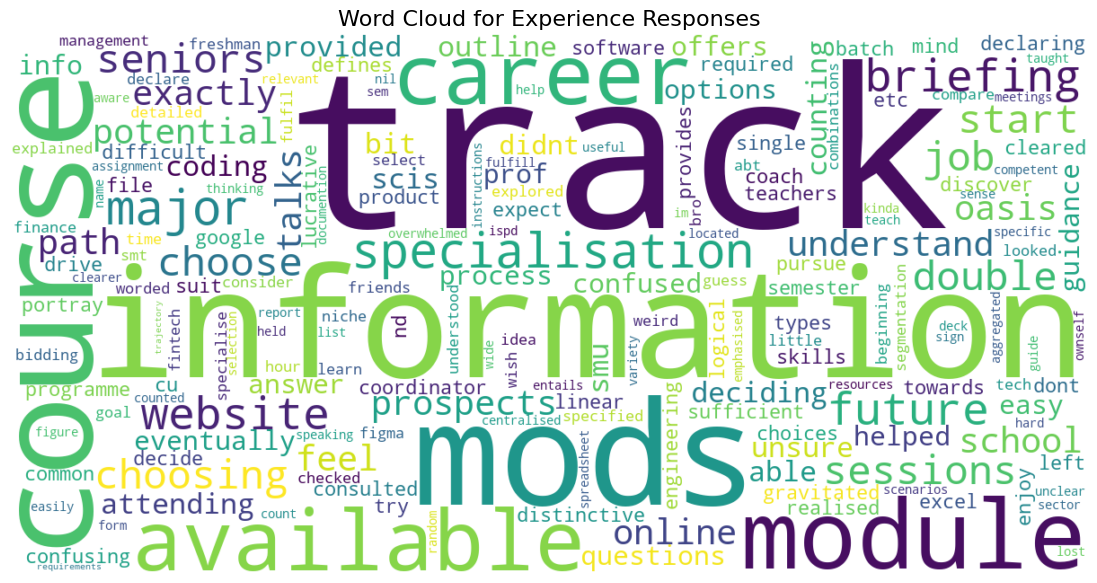

In [11]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt
 
# join all cleaned responses into one text string

text_for_wc = " ".join(

    df["experience_clean"].fillna("").astype(str)

)
 
# optional: remove empty space-only strings

text_for_wc = text_for_wc.strip()
 
# generate word cloud

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white",

    collocations=False

).generate(text_for_wc)
 
# plot

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud for Experience Responses", fontsize=16)

plt.show()

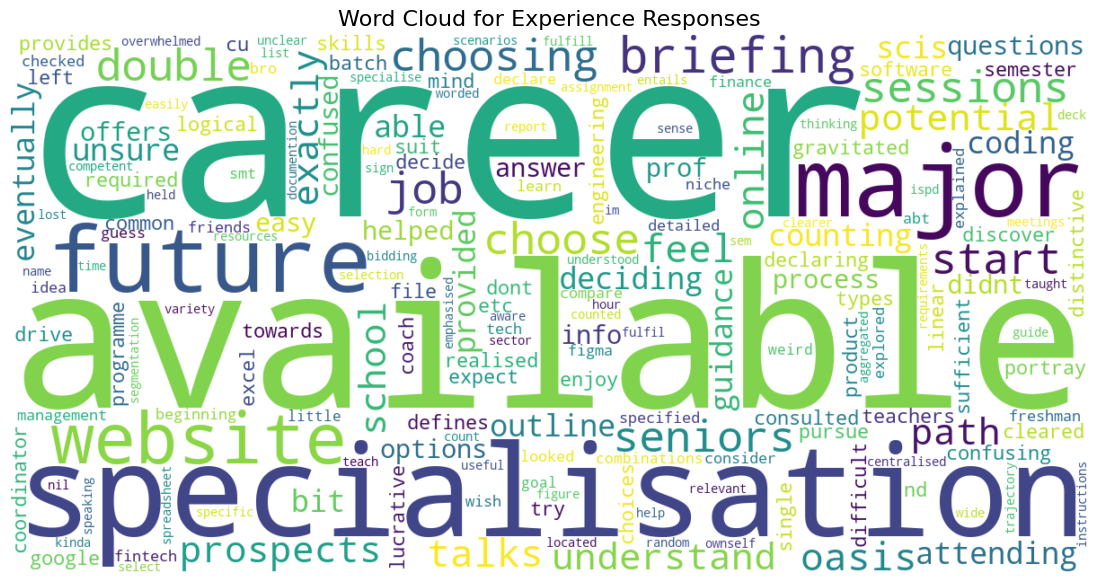

In [12]:
custom_remove = {"track", "tracks", "module", "modules", "information", "course", "courses", "smu", "mods"}
 
text_for_wc = " ".join(
    " ".join(word for word in str(text).split() if word not in custom_remove)
    for text in df["experience_clean"].fillna("")
)
 
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(text_for_wc)
 
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Experience Responses", fontsize=16)
plt.show()

In [13]:
import re
import pandas as pd
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# download once
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def pre_process(text, stopwords=None):
    if pd.isna(text):
        return ""
    
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    # text = re.sub(r"(\d|\W|_)+", " ", text)
    text=re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    
    # remove stopwords
    if stopwords:
        words = [w for w in words if w not in stopwords]
    
    # lemmatization (group similar words)
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return words   # return list instead of string

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jining\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jining\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [14]:
stopwords = get_stop_words("stopwords.txt")

df["tokens"] = df["experience"].apply(lambda x: pre_process(x, stopwords))

In [15]:
from collections import Counter

# flatten all words into one list
all_words = [word for tokens in df["tokens"] for word in tokens]

word_counts = Counter(all_words)

# convert to dataframe
word_df = pd.DataFrame(word_counts.items(), columns=["word", "count"])

# sort
word_df = word_df.sort_values(by="count", ascending=False)

word_df.head()

,word,count
24,track,28
20,information,10
11,mod,9
25,module,8
40,course,8


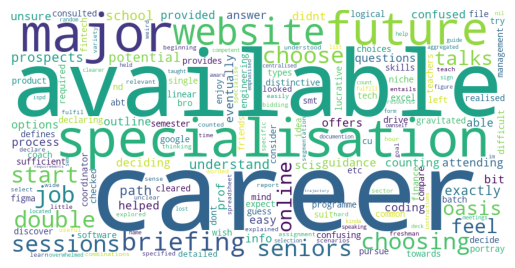

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# custom words to remove
custom_remove = {"track", "tracks", "module", "modules", "information", "course", "courses", "smu", "mods"}

# clean + combine text
text_for_wc = " ".join(
    " ".join(word for word in str(text).split() if word not in custom_remove)
    for text in df["experience_clean"].fillna("")
)

# generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_for_wc)

# plot
plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

text_data=df["experience_clean"].dropna()

vectorizer = TfidfVectorizer(

stop_words="english",

ngram_range=(2, 3),   # THIS is the key 🔥

max_features=30

)

tfidf_matrix=vectorizer.fit_transform(text_data)

feature_names=vectorizer.get_feature_names_out()

scores=tfidf_matrix.sum(axis=0).A1

tfidf_df= (

pd.DataFrame({"phrase": feature_names, "score": scores})

.sort_values(by="score", ascending=False)

)

tfidf_df.head(20)

,phrase,score
10,major talks,2.000000
9,information online,2.000000
11,modules double,2.000000
8,information available,1.414080
7,available track,1.248154
13,track modules,1.248154
12,smu website,1.214018
29,weren modules,1.000000
28,weird understand,1.000000
25,website seniors,0.739669


In [18]:
custom_stopwords= [
"track", "tracks", "information", "module", "modules",
"course", "courses", "smu", "scis"
]
vectorizer=TfidfVectorizer(
stop_words="english",
ngram_range=(2, 3),
max_features=30
)
vectorizer.set_params(stop_words=list(vectorizer.get_stop_words()) +custom_stopwords)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['beside', 'sincere', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer

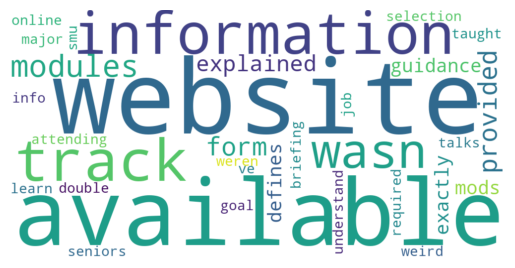

In [19]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

text=" ".join(tfidf_df["phrase"])
wordcloud=WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()